In [2]:
%load_ext autoreload
%autoreload 2
import os
import sys

In [3]:
import json
import pandas as pd
import requests
from tqdm import tqdm
import time
import duckdb
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()
REPO = os.getenv("REPO_PATH")
sys.path.append(os.path.join(REPO, 'src'))
import validation_utils as val 

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas import SingleTurnSample 
from ragas.metrics import ResponseRelevancy, Faithfulness, AspectCritic, FactualCorrectness, BleuScore, RougeScore, SemanticSimilarity
from ragas.metrics._string import NonLLMStringSimilarity, DistanceMeasure
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import RubricsScore

from openai import OpenAI
from ragas.llms import llm_factory
from openai import AsyncOpenAI

In [4]:
client = AsyncOpenAI(
    api_key=os.getenv("SURF_API_KEY"),
    base_url=os.getenv("SURF_API_BASE"),
)

llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="mistralai/Devstral-Small-2-24B-Instruct-2512",
        api_key=os.getenv("SURF_API_KEY"),
        base_url=os.getenv("SURF_API_BASE"),
        temperature=0,      # deterministic judging
        max_tokens=2048,    # headroom for structured output; too low truncates the JSON
    )
)

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_14685/2022125049.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  llm = LangchainLLMWrapper(


In [46]:
folder_predictions = os.path.join(REPO, 'data/predictions')
list_pred_pangaea = [f for f in os.listdir(folder_predictions) if f.startswith('pangaea')]

In [47]:
df_metadata_annot = pd.read_csv(os.path.join(REPO, 'outputs/pangaea/sample_20260629_163144_filtered_top5_per_topic.csv'))
col_names = ['name', 'description', 'keywords']
df_scores = df_metadata_annot.copy()

In [48]:
def serialize_dataset(df) -> str:
    # schema + stats + a sample beats raw rows: the judge reasons about
    # structure, not a lucky/unlucky row draw
    schema = "\n".join(f"- {c} ({t})" for c, t in df.dtypes.items())
    sample = df.head(5).to_markdown(index=False)
    return f"Columns:\n{schema}\n\nSample rows:\n{sample}\n\nRow count: {len(df)}"

async def score_all_abstracts(llm, df_merge, col_names, verbose=0, normalise=True):
    grounding_rubrics = {
        "score1_description": "Makes claims that contradict the data or reference fields/values that do not exist in it.",
        "score2_description": "Several claims are unsupported by the data or appear invented.",
        "score3_description": "Mostly supportable, but contains at least one unsupported or speculative claim.",
        "score4_description": "Every claim is supportable from the data; some claims are vague or generic.",
        "score5_description": "Every claim is directly supported by the data and is specific to it.",
    }
    scorer_faith = RubricsScore(rubrics=grounding_rubrics, llm=llm)
    scorer_sim = FactualCorrectness(llm=llm, mode="precision", atomicity="low")

    scores_faith = {}
    scores_sim = {}
    metadata_dict = {}
    order_metadata = ['full_abstract_pred', 'full_abstract_annot', 'data_ctx']
    for ii in tqdm(range(len(df_merge))):
        name = int(df_merge.iloc[ii]['id'])
        try:
            tmp = await score_faithfulness_abstract(scorer_faith, df_merge, ii, col_names, verbose)
            scores_faith[name] = tmp[0]
            if normalise:
                scores_faith[name] = (scores_faith[name] - 1) / 4   # normalise to 0–1
            metadata_dict[name] = {}
            for k, v in zip(order_metadata, tmp[1]):
                metadata_dict[name][k] = v

            tmp = await score_similarity_description(scorer_sim, df_merge, ii, col_names, verbose)
            scores_sim[name] = tmp
        except Exception as e:
            scores_faith[name] = None
            scores_sim[name] = None
            metadata_dict[name] = None
            print(f"row {name} failed: {e}")

    return scores_faith, scores_sim, metadata_dict

async def score_similarity_description(scorer, df_merge, ii, col_names, verbose=0):
    sample = SingleTurnSample(
        response=df_merge.iloc[ii]["description_pred"],
        reference=df_merge.iloc[ii]["description_annot"],
    )
    fc = await scorer.single_turn_ascore(sample)   # 0–1
    return fc

async def score_faithfulness_abstract(scorer, df_merge, ii, col_names, verbose=0):
    dataset_id = df_merge.iloc[ii]['id']
    df_tmp = pd.read_csv(REPO + f'outputs/pangaea/pangaea_datasets/{dataset_id}.csv')
    data_ctx = serialize_dataset(df_tmp)   # NOT df_merge (the annotations)
    if verbose:
        print(data_ctx)

    extracted_fields_annot = {col: df_merge.iloc[ii][f"{col}_annot"] for col in col_names}
    full_abstract_annot = '\n\n'.join(f'{k}: {v}' for k, v in extracted_fields_annot.items())
    
    extracted_fields_pred = {col: df_merge.iloc[ii][f"{col}_pred"] for col in col_names}
    full_abstract_pred = '\n\n'.join(f'{k}: {v}' for k, v in extracted_fields_pred.items())
    
    if verbose:
        print(full_abstract_annot)
        print(full_abstract_pred)

    sample = SingleTurnSample(
        user_input=(
            f"A model generated metadata for a dataset from the data alone.\n\n"
            f"DATASET:\n{data_ctx}\n\n"
            f"Judge only whether the TITLE, DESCRIPTION, and KEYWORDS below are grounded in this data — "
            f"whether its claims could be inferred from the data. Do not reward or "
            f"penalize style, completeness, or omissions."
        ),
        response=full_abstract_pred,
    )

    score = await scorer.single_turn_ascore(sample)
    return score, (full_abstract_pred, full_abstract_annot, data_ctx)



In [12]:
for fname in list_pred_pangaea:
    try:
        print(f"Processing predictions from: {fname}\n")
        
        df_metadata_inferred = val.get_metadata_files(os.path.join(folder_predictions, fname))
        df_merge, df_pred, df_annot, metadata_fields_present = val.precheck_validate(df_pred=df_metadata_inferred, df_annot=df_metadata_annot)
        assert df_pred.model.nunique() == 1, "Multiple models found in predictions; expected only one."
        model_name = df_pred.model.unique()[0]
        if f'faith_{model_name}' in df_scores.columns:
            print(f"skipping {model_name} (already scored)")
            continue
        scores_faith, scores_sim, metadata_dict = await score_all_abstracts(llm, df_merge, col_names)

        df_scores[f'faith_{model_name}'] = df_scores.id.map(scores_faith)
        df_scores[f'sim_{model_name}'] = df_scores.id.map(scores_sim)
        df_scores.to_csv(REPO + 'outputs/pangaea/df_scores_checkpoint.csv', index=False)  # persist per model
    except Exception as e:
        print(f"{fname} failed: {e}")
        continue

Processing predictions from: pangaea_llama3_70B

Dropping columns from df_pred: ['license', 'spatial', 'spatialCoverage', 'temporal', 'temporalCoverage', 'fileset', 'recordset']


100%|██████████| 75/75 [13:08<00:00, 10.51s/it]


Processing predictions from: pangaea_mistralai_Mistral-Small-3.2-24B-Instruct-2506

Dropping columns from df_pred: ['license', 'spatial', 'spatialCoverage', 'temporal', 'temporalCoverage', 'fileset', 'recordset']


100%|██████████| 75/75 [16:43<00:00, 13.38s/it]


Processing predictions from: pangaea_Qwen_3.6_35B

Dropping columns from df_pred: ['license', 'spatial', 'spatialCoverage', 'temporal', 'temporalCoverage', 'fileset', 'recordset']


100%|██████████| 75/75 [13:21<00:00, 10.68s/it]


Processing predictions from: pangaea_Qwen3.5-122B

Dropping columns from df_pred: ['license', 'spatial', 'spatialCoverage', 'temporal', 'temporalCoverage', 'fileset', 'recordset']


100%|██████████| 75/75 [17:59<00:00, 14.39s/it]


In [49]:
df_scores = pd.read_csv(REPO + 'outputs/pangaea/df_scores_checkpoint.csv')

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_14685/1815824666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_14685/1815824666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')


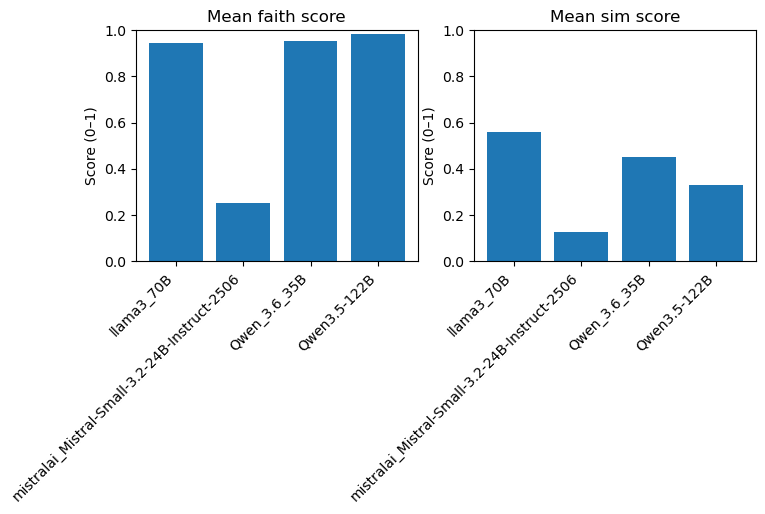

In [50]:
cols_metrics = [c for c in df_scores.columns if c.startswith('faith_') or c.startswith('sim_')]
df_scores[cols_metrics].mean()

model_names = ['_'.join(c.split('_')[1:]) for c in cols_metrics if c.startswith('faith_')]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
import numpy as np
for iplot, metric in enumerate(['faith', 'sim']):
    means = [df_scores[f'{metric}_{m}'].mean() for m in model_names]
    ax[iplot].bar(model_names, means)
    ax[iplot].set_title(f'Mean {metric} score')
    ax[iplot].set_ylim(0, 1)
    ax[iplot].set_ylabel('Score (0–1)')
    ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')

In [87]:
df_scores[df_scores.name =='Total organic carbon and total inorganic carbon content data of sediment core GeoB16310-3 from a coral mound in the Campeche Mound Province, Gulf of Mexico, MARIA S. MERIAN cruise MSM20/4']


def retrieve_metadata_by_id(df_scores, dataset_id, model='llama3_70B'):
    assert model in model_names, f"Model {model} not found in model_names: {model_names}"

    df_tmp = pd.read_csv(REPO + f'outputs/pangaea/pangaea_datasets/{dataset_id}.csv')
    data_context = serialize_dataset(df_tmp)

    row = df_scores[df_scores.id == dataset_id]

    path_pred = os.path.join(REPO, 'data/predictions', f'pangaea_{model}')
    tmp_files = [x for x in os.listdir(path_pred) if x.startswith(f'{dataset_id}')]
    path_pred = os.path.join(path_pred, tmp_files[0]) if tmp_files else None
    assert os.path.exists(path_pred), f"Prediction file not found: {path_pred}"

    with open(path_pred, 'r') as f:
        pred_data = json.load(f)

    print(model)
    return row, data_context, pred_data

tmp = retrieve_metadata_by_id(df_scores, 987068, model=model_names[2])  # pick the last model for demonstration

print(tmp[1])

print(tmp[0].keywords.values)

print(tmp[2])

Qwen_3.6_35B
Columns:
- Depth sed (float64)
- TOC (float64)
- TIC (float64)
- Event (object)
- Latitude (float64)
- Longitude (float64)
- Elevation (float64)
- Date/Time (object)

Sample rows:
|   Depth sed |   TOC |    TIC | Event       |   Latitude |   Longitude |   Elevation | Date/Time           |
|------------:|------:|-------:|:------------|-----------:|------------:|------------:|:--------------------|
|        0.1  | 0.603 |  9.997 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        0.4  | 0.644 | 10.056 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        0.75 | 0.58  | 10.02  | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        1.05 | 0.577 | 10.323 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        1.35 | 0.626 | 10.274 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |

Row count: 23
["['Campeche Bank', 'c

Text(0.5, 1.1, 'Score distributions for model: Qwen3.5-122B\n')

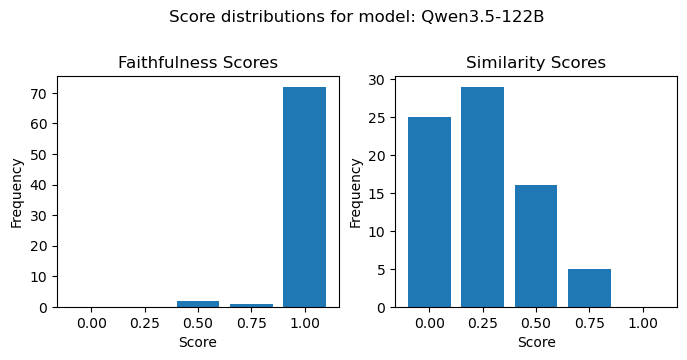

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

model = model_names[-1]  # pick the first model for histogram plotting

ax[0].hist(df_scores[f'faith_{model}'].values, bins=5, range=(0, 1.25), align='left', rwidth=0.8)
ax[0].set_title('Faithfulness Scores')
ax[0].set_xlabel('Score')
ax[0].set_ylabel('Frequency')

ax[1].hist(df_scores[f'sim_{model}'].values, bins=5, range=(0, 1.25), align='left', rwidth=0.8)
ax[1].set_title('Similarity Scores')
ax[1].set_xlabel('Score')
ax[1].set_ylabel('Frequency')

fig.suptitle(f"Score distributions for model: {model}\n", y=1.1)

In [63]:
target_score = 1

ids_target_score = df_scores[df_scores[f'faith_{model}'] == target_score].id.values

In [66]:
df_scores[df_scores.id == ids_target_score[1]][[f'faith_{model}', f'sim_{model}']]

,faith_Qwen3.5-122B,sim_Qwen3.5-122B
1,1.0,0.0


# Spatiotemporal eval

In [8]:
folder_predictions = os.path.join(REPO, 'data/predictions')
list_pred_inat = [f for f in os.listdir(folder_predictions) if f.startswith('inat')]

folder_data = os.path.join(REPO, 'outputs/inaturalist/inaturalist_100_species_1000_obs')

In [41]:
base_cols = ['min_lon', 'max_lon', 'min_lat', 'max_lat', 'min_time', 'max_time']
df_metadata = {
    x: []
    for x in ['id']
    + [f"{c}_annot" for c in base_cols]
    + [f"{c}_pred" for c in base_cols]
}

folder_pred = os.path.join(folder_predictions, list_pred_inat[0])

def fix_dt(dt_str):
    '''Final format: YYYY-MM-DDTHH:MM:SS
    '''
    if not dt_str or not isinstance(dt_str, str):
        return None
    
    if dt_str[-1] == 'Z':
        dt_str = dt_str[:-1]

    if len(dt_str) == 10:
        dt_str = dt_str + 'T00:00:00'
    elif len(dt_str) == 16 and dt_str[10] == 'T' and dt_str[13] == ':':
        dt_str = dt_str + ':00'

    return dt_str

for f in os.listdir(folder_data):
    species_name = f.replace('.csv', '').replace('_', ' ')
    df_sel = pd.read_csv(os.path.join(folder_data, f))
    lon = df_sel['decimalLongitude']
    lat = df_sel['decimalLatitude']
    min_lon, max_lon = lon.min(), lon.max()
    min_lat, max_lat = lat.min(), lat.max()

    df_sel['eventDate_fixed'] = df_sel['eventDate'].map(fix_dt)
    df_sel['datetime'] = pd.to_datetime(df_sel['eventDate_fixed'], errors='coerce')
    assert df_sel['datetime'].isnull().sum() == 0, f"Some datetime values could not be parsed: {df_sel[df_sel['datetime'].isnull()]['eventDate'].tolist()}"
    min_time, max_time = df_sel['datetime'].min(), df_sel['datetime'].max()

    df_metadata['id'].append(species_name)
    df_metadata['min_lon_annot'].append(min_lon)
    df_metadata['max_lon_annot'].append(max_lon)
    df_metadata['min_lat_annot'].append(min_lat)
    df_metadata['max_lat_annot'].append(max_lat)
    df_metadata['min_time_annot'].append(min_time)
    df_metadata['max_time_annot'].append(max_time)

    df_pred = pd.read_json(os.path.join(folder_pred, f"{species_name.replace(' ', '_')}_inaturalist.json"), orient='records')
    df_metadata['min_lon_pred'].append(df_pred.loc['min_lon', 'spatialCoverage'])
    df_metadata['max_lon_pred'].append(df_pred.loc['max_lon', 'spatialCoverage'])
    df_metadata['min_lat_pred'].append(df_pred.loc['min_lat', 'spatialCoverage'])
    df_metadata['max_lat_pred'].append(df_pred.loc['max_lat', 'spatialCoverage'])
    df_metadata['min_time_pred'].append(fix_dt(df_pred.loc['from', 'temporalCoverage']))
    df_metadata['max_time_pred'].append(fix_dt(df_pred.loc['to', 'temporalCoverage']))

df_metadata = pd.DataFrame(df_metadata)
df_metadata['min_time_pred'] = pd.to_datetime(df_metadata['min_time_pred'], errors='coerce').dt.tz_localize(None)
df_metadata['max_time_pred'] = pd.to_datetime(df_metadata['max_time_pred'], errors='coerce').dt.tz_localize(None)

In [45]:
for c in base_cols:
    print(c, (df_metadata[f'{c}_annot'] == df_metadata[f'{c}_annot']).sum())

min_lon 100
max_lon 100
min_lat 100
max_lat 100
min_time 100
max_time 100
